In [1]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib import pyplot as plt

from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
import re

import os
from tqdm import tqdm 
import re

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_act import ADModel_act
from ADModel_three_state import ADModel_three_state_abund
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode


os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [2]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [3]:
two_model_results = pd.read_csv('results/results_two_state_test_leakyrelu.csv')
shuffled_results = pd.read_csv('results/results_two_state_shuffles_hill.csv')

In [4]:
# two_model_results = two_model_results[two_model_results['kernel_size'] < 40]
two_model_results = two_model_results.sort_values("pearson_act_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r1"] = two_model_results.index

two_model_results = two_model_results.sort_values("spearman_act_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r2"] = two_model_results.index
two_model_results = two_model_results.drop(columns="level_0")

two_model_results["max_rank"] = two_model_results[["r1","r2",]].max(axis=1)            # min–max rule
two_model_results["sum_rank"] = two_model_results["r1"] + two_model_results["r2"]               # Borda

two_model_results.sort_values(["sum_rank"]) 

,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,...,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params,r1,r2,max_rank,sum_rank
11,665,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.528138,0.794913,...,0.846245,True,NaN,True,False,943,26,11,26,37
7,257,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.560292,0.795544,...,0.843270,True,NaN,True,False,1133,30,7,30,37
0,293,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.543562,0.792507,...,0.842450,True,NaN,False,False,1608,42,0,42,42
3,713,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.569492,0.797700,...,0.837627,True,NaN,False,False,1418,39,3,39,42
1,149,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.548511,0.790779,...,0.840176,True,NaN,True,False,1608,44,1,44,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2881,2477,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Linear,0.5,0.1,1,0.544156,0.050192,...,0.043315,False,NaN,True,False,1038,2881,2881,2881,5762
2882,797,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Linear,0.5,0.1,1,0.557629,-0.018637,...,0.016674,False,NaN,False,False,1608,2882,2882,2882,5764
2883,2237,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Linear,0.5,0.1,1,0.557629,-0.018637,...,0.016674,False,NaN,False,False,1608,2883,2883,2883,5766
2884,2633,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Linear,0.5,0.1,1,0.550544,0.024299,...,0.025102,False,NaN,True,False,1133,2884,2884,2884,5768


In [5]:
shuffled_results['shuffle_num'] = [int(re.search("SHUFFLE_(\d+)", model)[1]) for model in shuffled_results['model_name']]
shuffled_results['abund_k'] = [int(re.search(r'ak(\d+)',model).group(1)) for model in shuffled_results['model_name']]

In [6]:
shuffled_results = shuffled_results.sort_values("shuffle_num")

In [7]:
shuffled_results['shuffle_num'].value_counts()

shuffle_num
1     420
14    420
24    420
23    420
22    420
21    420
20    420
19    420
18    420
17    420
16    420
15    420
13    420
2     420
12    420
11    420
10    420
9     420
8     420
7     420
6     420
5     420
4     420
3     420
25    420
Name: count, dtype: int64

In [26]:
# Running the two-state biophysical model on the data

# Biophysical model parameters
size = (1,40,20)
hill_value = 1
relu = False
# relu = True
outchannel = 1

# Read in model and weights
def load_model_get_weights(row, layer1='conv1.weight', layer2="linear1.weight"): 
    model = row["model_name"].removeprefix("../../")
    kernel_size = row["kernel_size"]
    abund_k_two = row["abund_k"]
    activity_fun = row["activity_fun"]

    loaded_model = ADModel_two_state_abund(size,activity_fun, kernel_size, relu=relu, abund_k=abund_k_two)
    loaded_model.load_state_dict(torch.load(f"{model}.pth"))

    loaded_model.eval()
    model_state_dict = loaded_model.state_dict()
    width = model_state_dict[layer1].shape[0] * model_state_dict[layer1].shape[2]
    conv_weight = model_state_dict[layer1].detach().numpy().reshape(width,20)

    linear_weights_size = (40 - kernel_size + 1)
    linear_weights = model_state_dict[layer2].detach().numpy().reshape(linear_weights_size)
    # print(linear_weights)

    return loaded_model, conv_weight, linear_weights

# CHANGE
k_size = 40
num_shuffles = 25

# weight_ls dim
# Dim 1: Shuffle number
# Dim 2: seed
# Dim 3: kernel size
# Dim 4: aa num (20)
shuffled_weight_ls = np.zeros((num_shuffles+1, 60, k_size, 20))
shuffled_linear_weight_ls = np.zeros((num_shuffles+1, 60, (40 - k_size + 1)))
i = 0
for index in tqdm(shuffled_results[shuffled_results['kernel_size'] == k_size].index):
    row = shuffled_results.loc[index]
    model = row["model_name"].removeprefix("../../")
    shuffle_number = row['shuffle_num']
    _, conv_weights, linear_weights = load_model_get_weights(row)

    shuffled_weight_ls[shuffle_number - 1, i, :, :] = conv_weights #.reshape(100, )
    shuffled_linear_weight_ls[shuffle_number - 1, i, :] = linear_weights

    if i < 59: 
        i +=1 
    else:
        i = 0

100%|██████████| 3000/3000 [10:37<00:00,  4.70it/s] 


In [27]:
filtered_two_model_results = two_model_results[(two_model_results['kernel_size'] == k_size) & (two_model_results['activity_fun'] == 'Hill') & (two_model_results['negative_pen'] == 0.5) &  (two_model_results['weight_pen'] == 0.1) & (two_model_results['hill_value'] == 1)]

filtered_two_model_results['seed'] = [int(re.search("seed(\d+)", model)[1]) for model in filtered_two_model_results['model_name']]
filtered_two_model_results['abund_k'] = [int(re.search(r'ak(\d+)',model).group(1)) for model in filtered_two_model_results['model_name']]
filtered_two_model_results = filtered_two_model_results[['hv0' not in name for name in filtered_two_model_results['model_name']]]
filtered_two_model_results = filtered_two_model_results.reset_index()
filtered_two_model_results.sort_values(["sum_rank"]).head() # Best at index 0

/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_50142/2079387050.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_two_model_results['seed'] = [int(re.search("seed(\d+)", model)[1]) for model in filtered_two_model_results['model_name']]
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_50142/2079387050.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_two_model_results['abund_k'] = [int(re.search(r'ak(\d+)',model).group(1)) for model in filtered_two_model_results['m

,level_0,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,...,K2_negative,abund_negative,relu,total_params,r1,r2,max_rank,sum_rank,seed,abund_k
5,7,257,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.560292,...,NaN,True,False,1133,30,7,30,37,1793115,15
8,11,665,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.528138,...,NaN,True,False,943,26,11,26,37,1298091,5
0,0,293,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.543562,...,NaN,False,False,1608,42,0,42,42,1793115,40
3,3,713,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.569492,...,NaN,False,False,1418,39,3,39,42,1298091,30
1,1,149,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.548511,...,NaN,True,False,1608,44,1,44,45,8923039,40


In [10]:
real_weight_ls = np.zeros((1, 60, k_size, 20))
real_linear_weight_ls = np.zeros((1, 60, (40 - k_size + 1)))

for i, index in enumerate(tqdm(filtered_two_model_results[filtered_two_model_results['kernel_size'] == k_size].index)):
    # if i == 30:
    #     break
    _, conv_weights, linear_weights = load_model_get_weights(filtered_two_model_results.loc[index])

    real_weight_ls[0, i, :, :] = conv_weights #.reshape(100, )
    real_linear_weight_ls[0, i, :] = linear_weights #.reshape(100, )


100%|██████████| 60/60 [00:49<00:00,  1.22it/s]


# Statistical testing using these weights

## Sum of weights

In [28]:
neg_weight_filter = (real_linear_weight_ls < 0).all(axis=2)
neg_weight_filter

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False]])

In [29]:
real_weight_ls.shape

(1, 60, 40, 20)

In [30]:
real_weight_ls[0, :, :, i].sum(axis=1)

array([14.857, 13.005, 12.861, 13.214, 10.967, 12.510, 11.551, 12.785,
       14.915, 17.038, 14.283, 14.933, 14.282, -13.289, -9.437, -8.643,
       -10.664, -10.595, -9.905, -10.227, -8.142, -10.280, -8.180,
       -10.977, -6.693, -10.030, -10.603, -6.592, -10.506, -8.702, -7.552,
       -10.796, -6.901, -8.300, -6.318, -6.513, -10.065, -9.163, -6.765,
       -7.265, -6.345, -8.802, -7.591, -12.365, -9.839, -8.378, -8.654,
       -9.345, -9.271, -9.982, -8.330, -9.845, -6.737, -7.732, -6.763,
       -6.364, -9.547, -8.289, -6.368, -5.502])

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:00<00:00, 2344.34it/s]


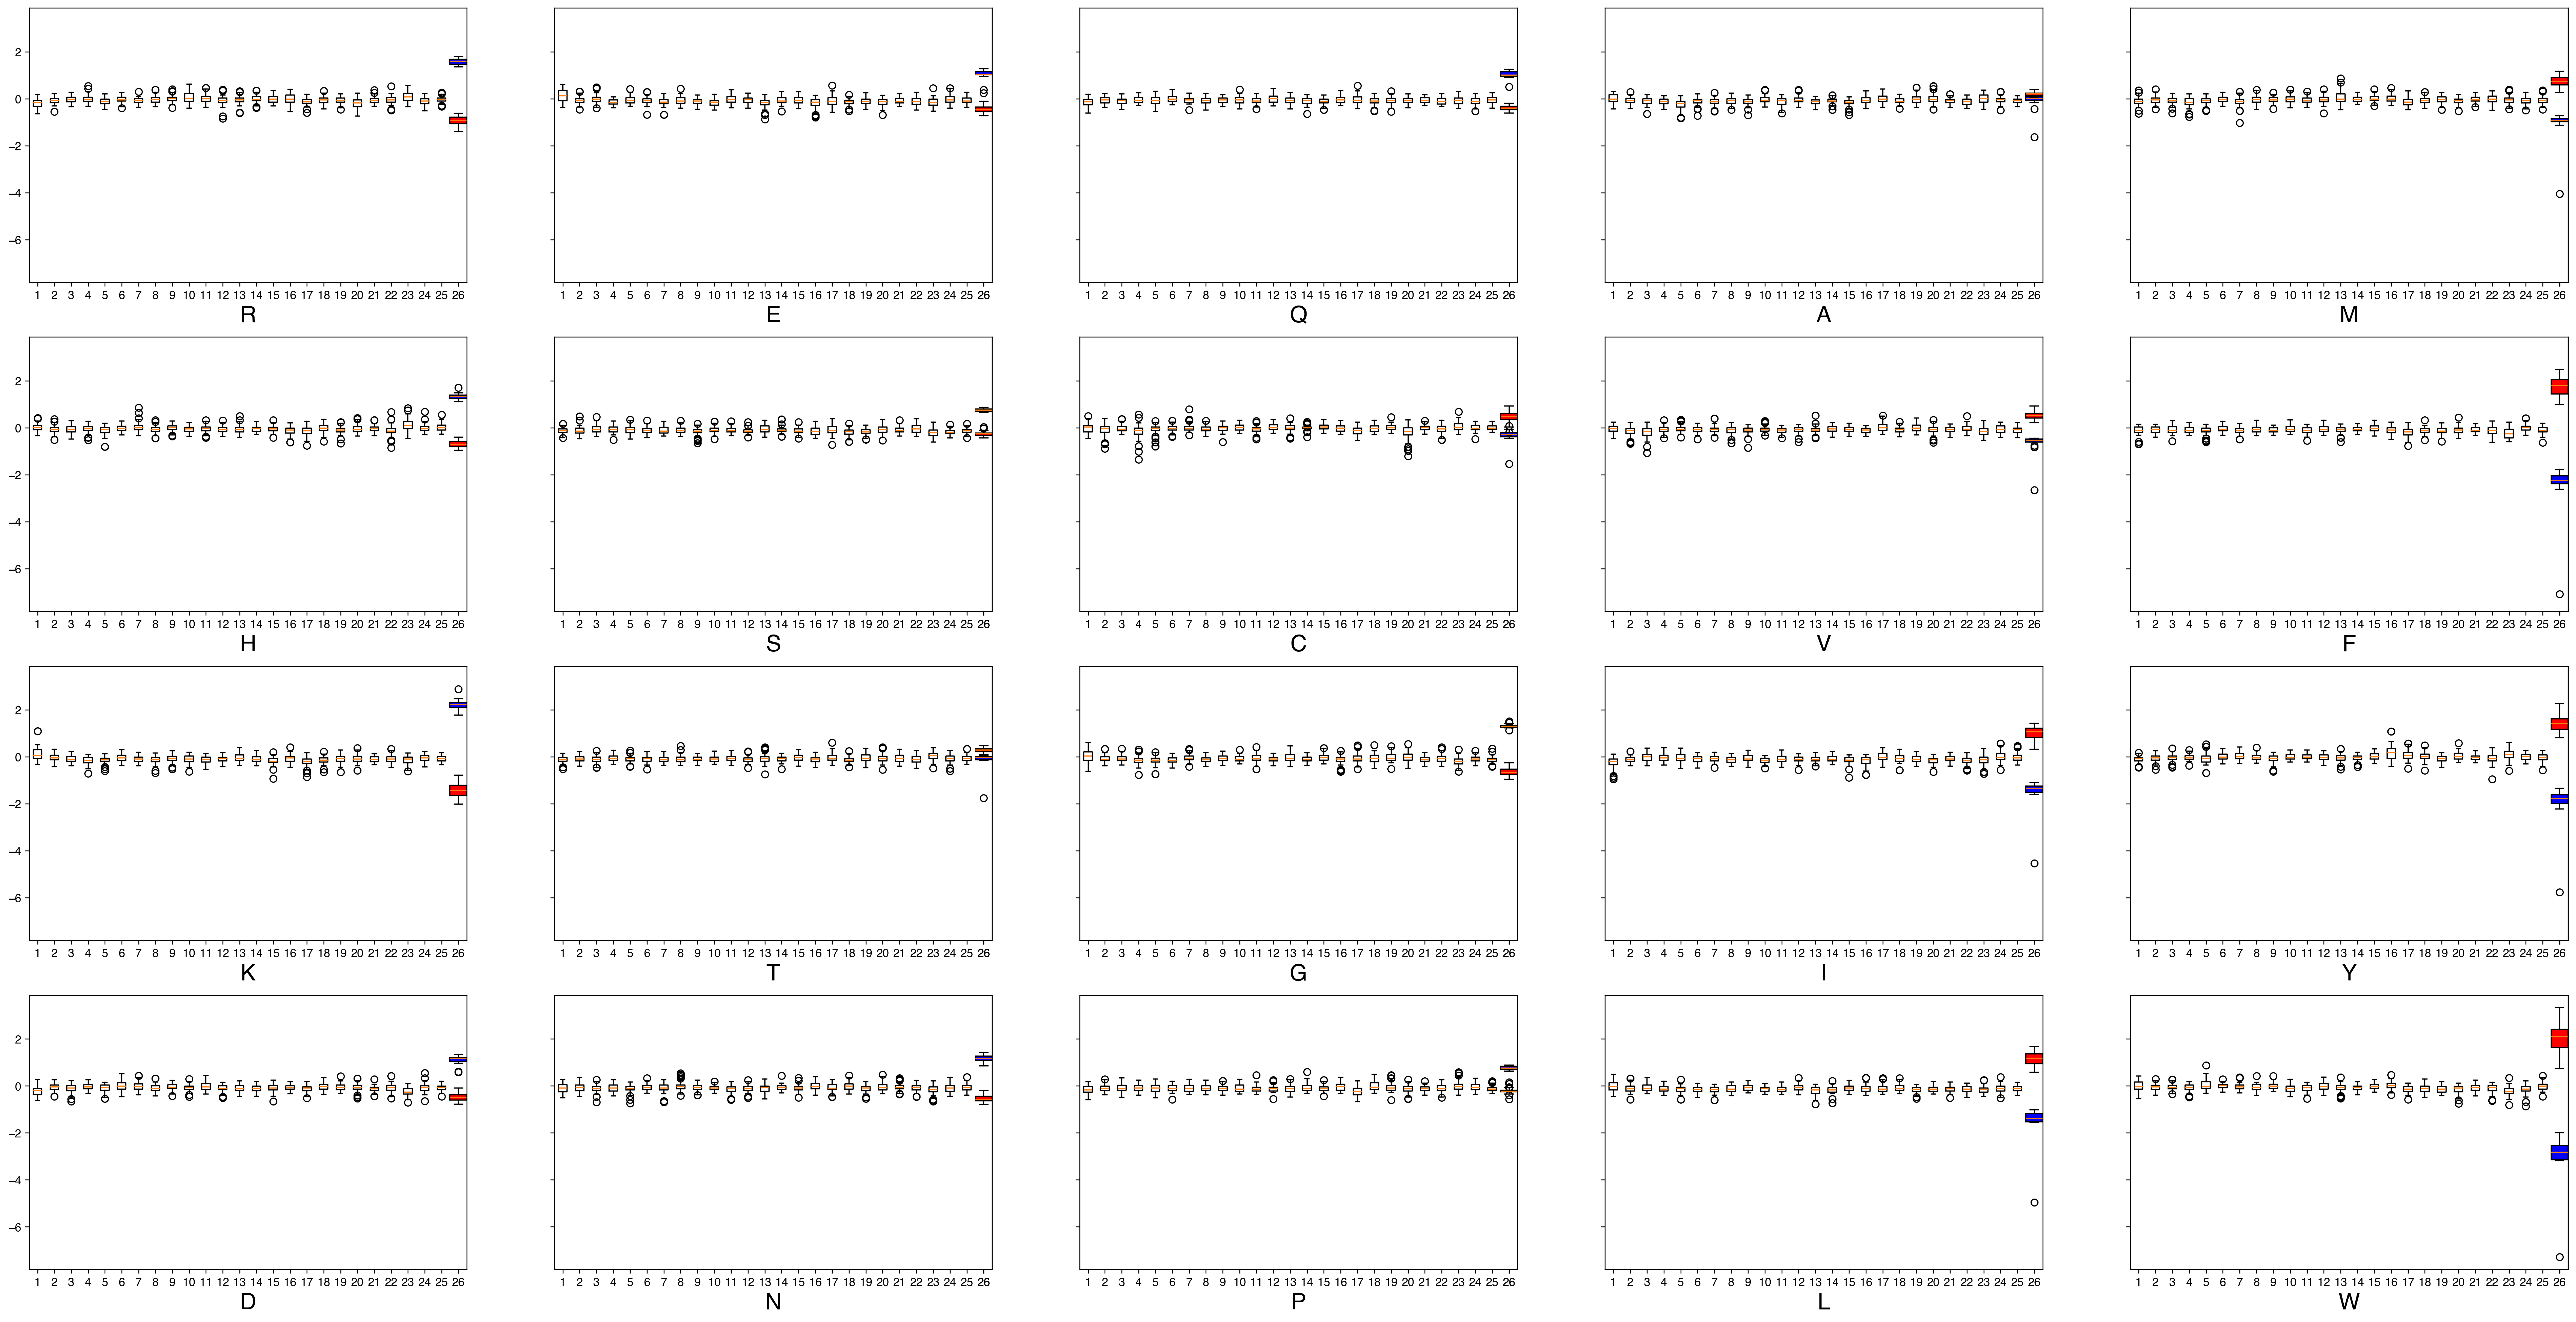

In [45]:
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"] 

# weight_ls dim
# Dim 1: Shuffle number
# Dim 2: seed
# Dim 3: kernel size
# Dim 4: aa num (20)

# var_ls dim
# Dim 1: Shuffle #
# Dim 2: Seed
# Dim 3: Sum 
sum_ls = np.zeros((num_shuffles, 60, 20))

# i loops through shuffles
for i in tqdm(range(0, num_shuffles)):

    for j in range(20):
        weight_sum = np.sum(shuffled_weight_ls[i, :, 35:, j], axis=1)
        sum_ls[i-1, :, j] = weight_sum


fig, axs = plt.subplots(4, 5, figsize=(40, 20), sharey=True)

row_idx = 0
col_idx = 0

for i in range(0, 20):

    axs[row_idx, col_idx].boxplot(sum_ls[:, :, i].T)

    real_weight_sum = real_weight_ls[0, :, 35:, i].sum(axis=1)
    # Only looking at + weight filters
    axs[row_idx, col_idx].boxplot(real_weight_sum[neg_weight_filter.squeeze()], positions=[num_shuffles + 1], 
                                  widths=1.0, patch_artist=True, boxprops=dict(facecolor='blue'))

    # Only looking at - weight filters
    axs[row_idx, col_idx].boxplot(real_weight_sum[~ neg_weight_filter.squeeze()], positions=[num_shuffles + 1], 
                                   widths=1.0, patch_artist=True, boxprops=dict(facecolor='red'))

    axs[row_idx, col_idx].set_xlabel(aa_order[i], fontsize=20)

    row_idx += 1
    if row_idx == 4:
        row_idx = 0
        col_idx += 1

plt.show()

In [166]:
D_weight.shape

(60, 40)

In [168]:
D_weight[neg_weight_filter.squeeze()]

array([[0.010, -0.029, -0.023, ..., -0.058, -0.041, -0.118],
       [0.044, 0.024, 0.010, ..., 0.065, 0.075, 0.037],
       [0.014, 0.020, 0.025, ..., 0.031, 0.086, 0.053],
       ...,
       [0.034, -0.016, 0.002, ..., 0.047, 0.061, 0.051],
       [0.016, 0.019, -0.035, ..., 0.073, 0.096, 0.051],
       [-0.044, 0.013, -0.011, ..., 0.045, 0.038, 0.060]])

In [15]:
slopes = []
D_weight = real_weight_ls[0, :, :, 12]
D_weight = D_weight[~neg_weight_filter.squeeze()]
for i in tqdm(range(0, len(D_weight))):
    slopes.append(np.polyfit(range(0, 40), D_weight[i], deg=1))
slopes

100%|██████████| 47/47 [00:00<00:00, 4504.03it/s]


[array([0.000, -0.036]),
 array([0.002, -0.038]),
 array([0.002, -0.055]),
 array([0.003, -0.055]),
 array([0.003, -0.070]),
 array([0.003, -0.060]),
 array([0.003, -0.068]),
 array([0.003, -0.061]),
 array([0.003, -0.080]),
 array([0.002, -0.050]),
 array([0.003, -0.048]),
 array([0.002, -0.032]),
 array([0.003, -0.064]),
 array([0.002, -0.059]),
 array([0.002, -0.050]),
 array([0.003, -0.054]),
 array([0.002, -0.051]),
 array([0.003, -0.052]),
 array([0.003, -0.078]),
 array([0.001, -0.026]),
 array([0.002, -0.044]),
 array([0.002, -0.040]),
 array([0.001, -0.038]),
 array([0.002, -0.055]),
 array([0.003, -0.061]),
 array([0.002, -0.031]),
 array([0.002, -0.050]),
 array([0.002, -0.040]),
 array([0.002, -0.040]),
 array([0.003, -0.062]),
 array([0.003, -0.054]),
 array([0.003, -0.059]),
 array([0.002, -0.056]),
 array([0.002, -0.051]),
 array([0.002, -0.054]),
 array([0.002, -0.038]),
 array([0.002, -0.058]),
 array([0.002, -0.049]),
 array([0.003, -0.064]),
 array([0.002, -0.043]),


In [174]:
D_weight_shuffle.shape

(11, 60, 40)

In [17]:
slopes_shuffle = []
D_weight_shuffle = shuffled_weight_ls[:, :, :, 12]
for i in tqdm(range(0, num_shuffles)):
    for j in tqdm(range(0, 60)):
        slopes_shuffle.append(np.polyfit(range(0, 40), D_weight_shuffle[i, j], deg=1))
slopes_shuffle

100%|██████████| 10/10 [00:00<00:00, 259.01it/s]


[array([0.002, -0.056]),
 array([-0.001, -0.009]),
 array([0.001, -0.060]),
 array([-0.001, 0.003]),
 array([0.000, -0.034]),
 array([-0.001, -0.018]),
 array([0.001, -0.035]),
 array([-0.001, -0.016]),
 array([0.000, -0.017]),
 array([-0.001, -0.009]),
 array([0.000, -0.035]),
 array([-0.000, -0.030]),
 array([0.000, -0.031]),
 array([0.001, -0.047]),
 array([0.000, -0.019]),
 array([-0.001, -0.014]),
 array([-0.000, -0.002]),
 array([-0.001, -0.019]),
 array([-0.000, 0.012]),
 array([0.001, -0.033]),
 array([0.001, -0.048]),
 array([-0.000, -0.015]),
 array([0.000, -0.025]),
 array([0.000, -0.020]),
 array([0.001, -0.028]),
 array([0.001, -0.050]),
 array([0.000, -0.018]),
 array([-0.000, -0.038]),
 array([0.000, -0.032]),
 array([0.001, -0.021]),
 array([-0.000, -0.002]),
 array([-0.000, -0.002]),
 array([0.001, -0.034]),
 array([-0.001, 0.011]),
 array([-0.002, 0.037]),
 array([-0.001, -0.014]),
 array([0.001, -0.057]),
 array([0.000, -0.017]),
 array([0.001, -0.026]),
 array([-0.0

(array([62.899, 0.000, 0.000, 125.798, 440.292, 440.292, 880.585, 566.090,
        314.495, 125.798]),
 array([0.000, 0.000, 0.001, 0.001, 0.001, 0.002, 0.002, 0.002, 0.003,
        0.003, 0.003]),
 <BarContainer object of 10 artists>)

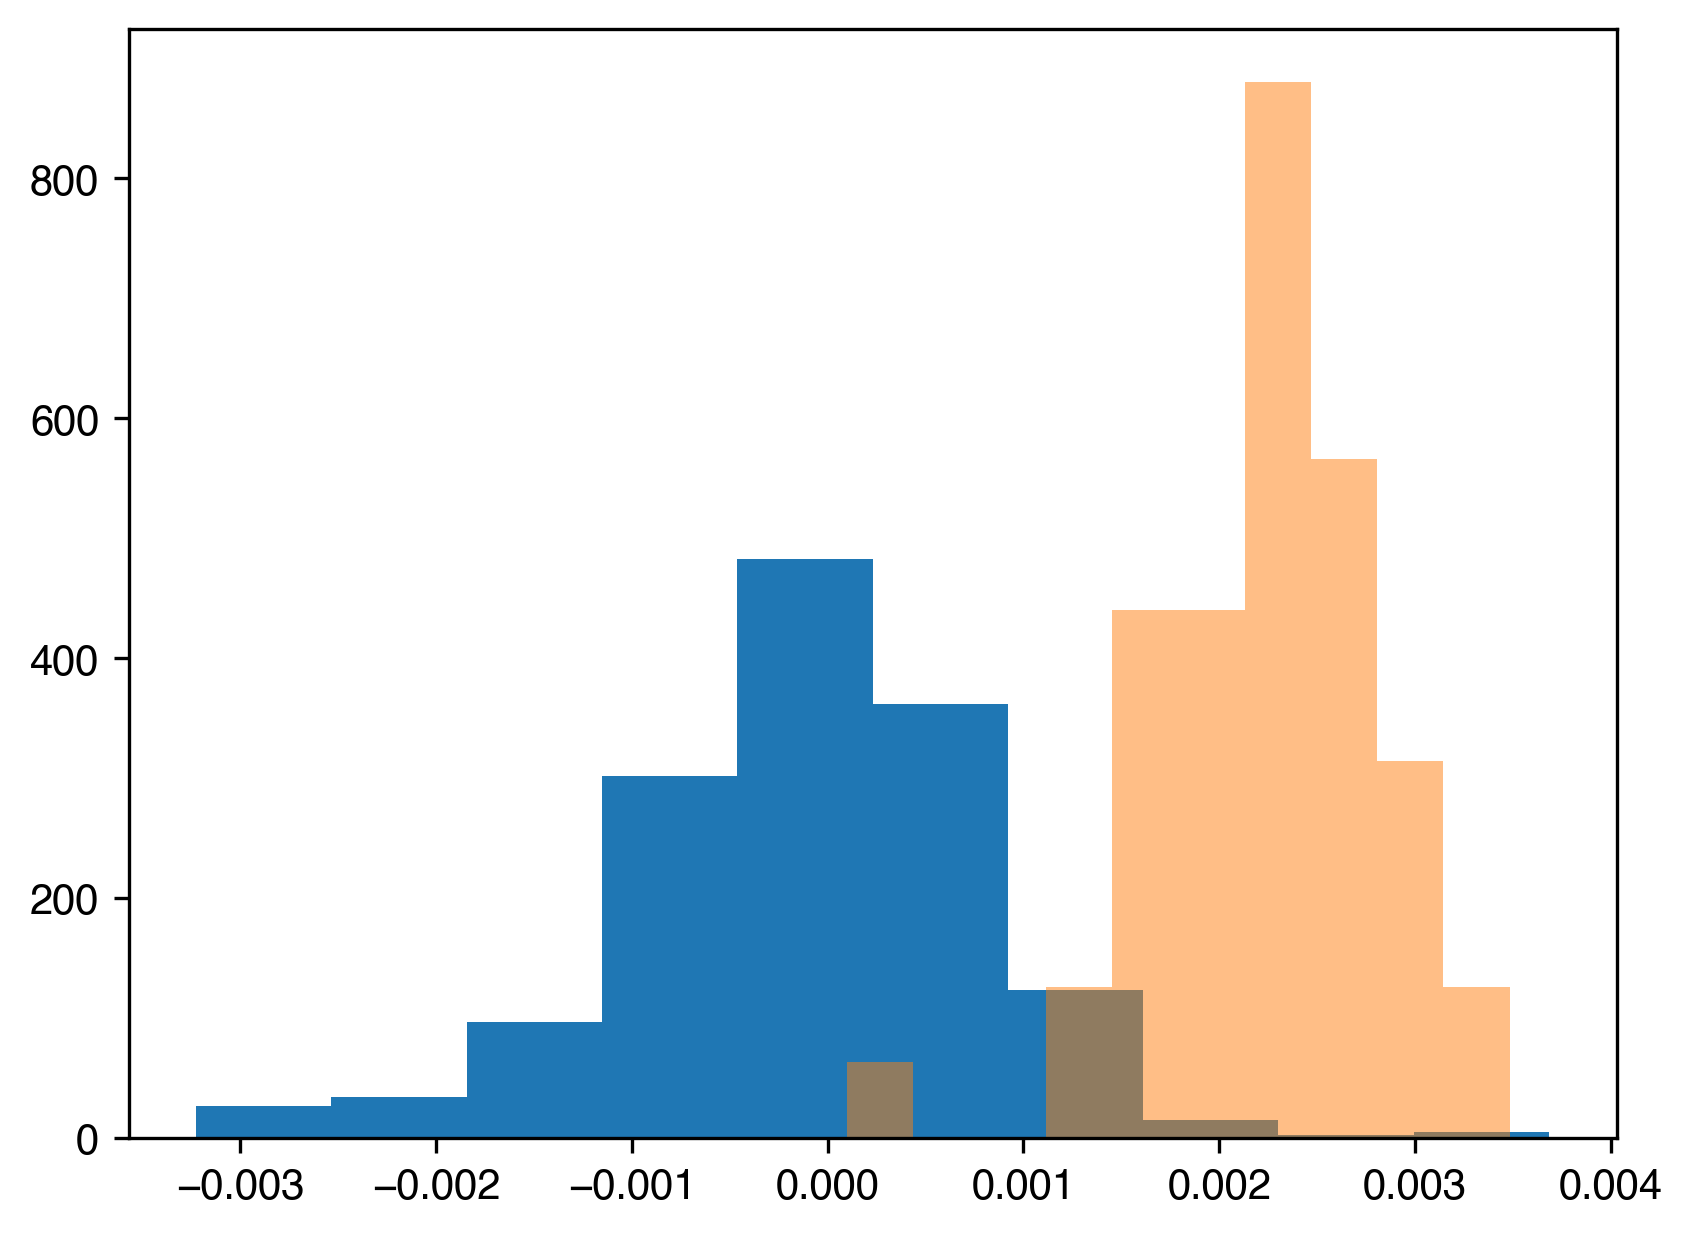

In [18]:
plt.hist([a[0] for a in slopes_shuffle], density=True)
plt.hist([a[0] for a in slopes], density=True, alpha=0.5)

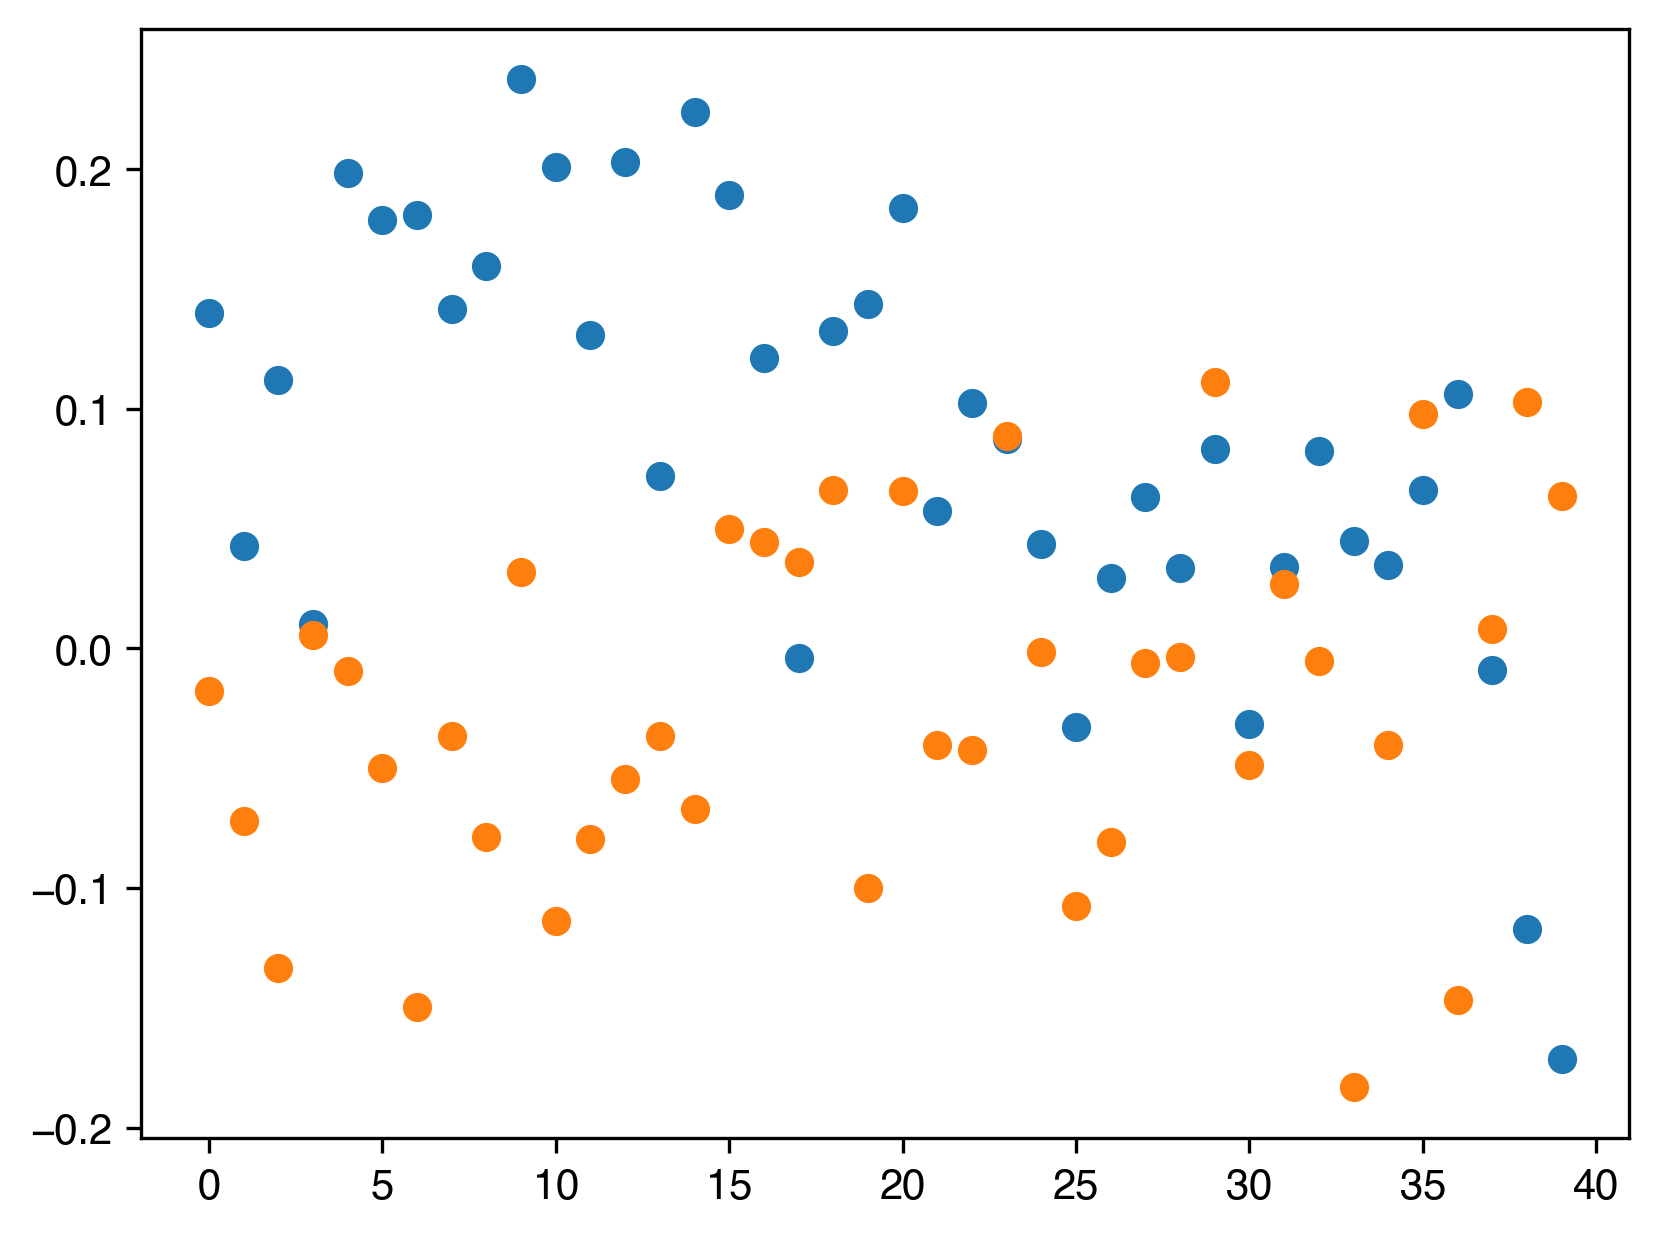

In [19]:
D_weight = real_weight_ls[0, :, :, 12]
D_weight_shuffle = shuffled_weight_ls[0, :, :, 12]
plt.scatter(range(0, 40), D_weight[0])
plt.scatter(range(0, 40), D_weight_shuffle[0])

In [20]:
# ONLY BEGINNING OF SEQUENCE
# Significantly smaller (more negative): 

sum_ls = np.zeros((num_shuffles, 60, 20))

# i loops through shuffles
for i in tqdm(range(0, num_shuffles)):

    for j in range(20):
        weight_sum = np.sum(shuffled_weight_ls[i, :, :, j], axis=1)
        sum_ls[i-1, :, j] = weight_sum
        
for i in range(0, 20):

    # Dim 1: Shuffle #
    # Dim 2: Seed number
    # Dim 3: sum
    shuffles = sum_ls[:, :, i].flatten() # extract row sum for amino acid i 

    # Sum for real weights 
    real_weight_sum = real_weight_ls[0, :, :10, i].sum(axis=1)

    # We filter out negative weights 
    neg_weight_filter = (real_linear_weight_ls > 0).all(axis=2)

    # Compare to the max (hardest comparison - messed up by negative weights)
    # Testing if our sum is significantly smaller than null
    # P-value counts how many of null are smaller than what we observe
    # To make it hard, we use the max value (it is easier to be smaller than the max value)
    # aka more of the null distribution will be smaller, giving us the largest possible p-value
    # Using the "best" model

    print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[neg_weight_filter.squeeze()].max()) / len(shuffles), end=", ")
    print(f"aa: {aa_order[i]}", sum(shuffles > real_weight_sum[~neg_weight_filter.squeeze()].min()) / len(shuffles))

    # print(real_weight_sum[0], np.mean(shuffles))
    # print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[0]) / len(shuffles))

100%|██████████| 10/10 [00:00<00:00, 1940.73it/s]

aa: R 0.175, aa: R 0.0
aa: H 0.6933333333333334, aa: H 0.6416666666666667
aa: K 0.06, aa: K 0.0
aa: D 1.0, aa: D 1.0
aa: E 0.985, aa: E 1.0
aa: S 0.925, aa: S 0.9766666666666667
aa: T 0.8933333333333333, aa: T 0.94
aa: N 0.8333333333333334, aa: N 0.71
aa: Q 0.8083333333333333, aa: Q 0.15833333333333333
aa: C 0.95, aa: C 0.8633333333333333
aa: G 0.8916666666666667, aa: G 0.9216666666666666
aa: P 0.9183333333333333, aa: P 0.8283333333333334
aa: A 0.8433333333333334, aa: A 0.44333333333333336
aa: V 0.86, aa: V 0.47833333333333333
aa: I 0.93, aa: I 0.9933333333333333
aa: L 0.945, aa: L 0.995
aa: M 1.0, aa: M 1.0
aa: F 1.0, aa: F 1.0
aa: Y 1.0, aa: Y 1.0
aa: W 1.0, aa: W 1.0


In [21]:
# ONLY END OF THE SEQUENCE
sum_ls = np.zeros((num_shuffles, 60, 20))

# i loops through shuffles
for i in tqdm(range(0, num_shuffles)):

    for j in range(20):
        weight_sum = np.sum(shuffled_weight_ls[i, :, 35:, j], axis=1)
        sum_ls[i-1, :, j] = weight_sum

for i in range(0, 20):

    # Dim 1: Shuffle #
    # Dim 2: Seed number
    # Dim 3: sum
    shuffles = sum_ls[:, :, i].flatten() # extract row sum for amino acid i 

    # Sum for real weights 
    real_weight_sum = real_weight_ls[0, :, 35:, i].sum(axis=1)

    # We filter out negative weights 
    neg_weight_filter = (real_linear_weight_ls > 0).all(axis=2)

    # Compare to the max (hardest comparison - messed up by negative weights)
    # Testing if our sum is significantly smaller than null
    # P-value counts how many of null are larger than what we observe
    # To make it hard, we use the min value (it is easier to be larger than the min value)
    # aka more of the null distribution will be larger, giving us the largest possible p-value


    print(f"aa: {aa_order[i]}", sum(shuffles > real_weight_sum[neg_weight_filter.squeeze()].min()) / len(shuffles), end=", ")
    print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[~neg_weight_filter.squeeze()].max()) / len(shuffles))

    # print(real_weight_sum[0], np.mean(shuffles))
    # print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[0]) / len(shuffles))

100%|██████████| 10/10 [00:00<00:00, 1720.88it/s]

aa: R 1.0, aa: R 1.0
aa: H 1.0, aa: H 1.0
aa: K 1.0, aa: K 1.0
aa: D 1.0, aa: D 1.0
aa: E 1.0, aa: E 1.0
aa: S 0.9866666666666667, aa: S 1.0
aa: T 0.09333333333333334, aa: T 0.8816666666666667
aa: N 1.0, aa: N 1.0
aa: Q 1.0, aa: Q 1.0
aa: C 0.8683333333333333, aa: C 0.79
aa: G 1.0, aa: G 1.0
aa: P 0.985, aa: P 1.0
aa: A 0.9633333333333334, aa: A 0.9616666666666667
aa: V 0.9933333333333333, aa: V 0.03333333333333333
aa: I 0.021666666666666667, aa: I 0.0
aa: L 0.0, aa: L 0.0
aa: M 0.018333333333333333, aa: M 0.0033333333333333335
aa: F 0.0, aa: F 0.0
aa: Y 0.0, aa: Y 0.0
aa: W 0.0016666666666666668, aa: W 0.0


In [22]:
# ONLY END OF THE SEQUENCE
sum_ls = np.zeros((num_shuffles, 60, 20))

# i loops through shuffles
for i in tqdm(range(0, num_shuffles)):

    for j in range(20):
        weight_sum = np.sum(shuffled_weight_ls[i, :, 35:, j], axis=1)
        sum_ls[i-1, :, j] = weight_sum

for i in range(0, 20):

    # Dim 1: Shuffle #
    # Dim 2: Seed number
    # Dim 3: sum
    shuffles = sum_ls[:, :, i].flatten() # extract row sum for amino acid i 

    # Sum for real weights 
    real_weight_sum = real_weight_ls[0, :, 35:, i].sum(axis=1)

    # We filter out negative weights 
    neg_weight_filter = (real_linear_weight_ls > 0).all(axis=2)

    # Compare to the max (hardest comparison - messed up by negative weights)
    # Testing if our sum is significantly smaller than null
    # P-value counts how many of null are larger than what we observe
    # To make it hard, we use the min value (it is easier to be larger than the min value)
    # aka more of the null distribution will be larger, giving us the largest possible p-value


    print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[neg_weight_filter.squeeze()].max()) / len(shuffles), end=", ")
    print(f"aa: {aa_order[i]}", sum(shuffles > real_weight_sum[~neg_weight_filter.squeeze()].min()) / len(shuffles))

    # print(real_weight_sum[0], np.mean(shuffles))
    # print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[0]) / len(shuffles))

100%|██████████| 10/10 [00:00<00:00, 3144.63it/s]

aa: R 0.0016666666666666668, aa: R 0.0
aa: H 0.021666666666666667, aa: H 0.0
aa: K 0.0, aa: K 0.0
aa: D 1.0, aa: D 0.0
aa: E 0.97, aa: E 0.06
aa: S 0.72, aa: S 0.175
aa: T 1.0, aa: T 1.0
aa: N 0.22666666666666666, aa: N 0.0
aa: Q 0.22666666666666666, aa: Q 0.0
aa: C 1.0, aa: C 1.0
aa: G 0.13333333333333333, aa: G 0.0
aa: P 0.9333333333333333, aa: P 0.9966666666666667
aa: A 1.0, aa: A 1.0
aa: V 1.0, aa: V 1.0
aa: I 1.0, aa: I 1.0
aa: L 1.0, aa: L 1.0
aa: M 1.0, aa: M 1.0
aa: F 1.0, aa: F 1.0
aa: Y 1.0, aa: Y 1.0
aa: W 1.0, aa: W 1.0


In [202]:
real_weight_ls[0, 0].shape

(40, 20)

In [23]:
# Testing on best NN
# Significantly smaller (more negative): 
for i in range(0, 20):

    # Dim 1: Shuffle #
    # Dim 2: Seed number
    # Dim 3: sum
    shuffles = sum_ls[:, 30:, i].flatten() # extract row sum for amino acid i 

    # Sum for real weights 
    real_weight_sum = real_weight_ls[0, 0, 30:, i].sum(axis=0)

    # We filter out negative weights 
    neg_weight_filter = (real_linear_weight_ls > 0).all(axis=2)

    # Compare to the max (hardest comparison - messed up by negative weights)
    # Testing if our sum is significantly smaller than null
    # P-value counts how many of null are smaller than what we observe
    # To make it hard, we use the max value (it is easier to be smaller than the max value)
    # aka more of the null distribution will be smaller, giving us the largest possible p-value
    # Using the "best" model

    print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum) / len(shuffles), end=", ")
    print(f"aa: {aa_order[i]}", sum(shuffles > real_weight_sum) / len(shuffles))

    # print(real_weight_sum[0], np.mean(shuffles))
    # print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[0]) / len(shuffles))

aa: R 1.0, aa: R 0.0
aa: H 1.0, aa: H 0.0
aa: K 1.0, aa: K 0.0
aa: D 1.0, aa: D 0.0
aa: E 1.0, aa: E 0.0
aa: S 1.0, aa: S 0.0
aa: T 0.9133333333333333, aa: T 0.08666666666666667
aa: N 1.0, aa: N 0.0
aa: Q 1.0, aa: Q 0.0
aa: C 0.04, aa: C 0.96
aa: G 1.0, aa: G 0.0
aa: P 1.0, aa: P 0.0
aa: A 0.8566666666666667, aa: A 0.14333333333333334
aa: V 0.0, aa: V 1.0
aa: I 0.0, aa: I 1.0
aa: L 0.0, aa: L 1.0
aa: M 0.0, aa: M 1.0
aa: F 0.0, aa: F 1.0
aa: Y 0.0, aa: Y 1.0
aa: W 0.0, aa: W 1.0


In [24]:
# Significantly smaller (more negative): 
for i in range(0, 20):

    # Dim 1: Shuffle #
    # Dim 2: Seed number
    # Dim 3: sum
    shuffles = sum_ls[:, :, i].flatten() # extract row sum for amino acid i 

    # Sum for real weights 
    real_weight_sum = real_weight_ls[0, :, :, i].sum(axis=1)

    # We filter out negative weights 
    neg_weight_filter = (real_linear_weight_ls > 0).all(axis=2)

    # Compare to the max (hardest comparison - messed up by negative weights)
    # Testing if our sum is significantly smaller than null
    # P-value counts how many of null are smaller than what we observe
    # To make it hard, we use the max value (it is easier to be smaller than the max value)
    # aka more of the null distribution will be smaller, giving us the largest possible p-value
    # Using the "best" model

    print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[neg_weight_filter.squeeze()].max()) / len(shuffles), end=", ")
    print(f"aa: {aa_order[i]}", sum(shuffles > real_weight_sum[~neg_weight_filter.squeeze()].min()) / len(shuffles))

    # print(real_weight_sum[0], np.mean(shuffles))
    # print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[0]) / len(shuffles))

aa: R 0.0, aa: R 0.0
aa: H 0.0, aa: H 0.0
aa: K 0.0, aa: K 0.0
aa: D 1.0, aa: D 1.0
aa: E 1.0, aa: E 1.0
aa: S 0.035, aa: S 1.0
aa: T 0.9983333333333333, aa: T 1.0
aa: N 0.0, aa: N 0.0
aa: Q 0.0, aa: Q 0.0
aa: C 1.0, aa: C 1.0
aa: G 0.15, aa: G 1.0
aa: P 0.02, aa: P 1.0
aa: A 0.9083333333333333, aa: A 1.0
aa: V 1.0, aa: V 1.0
aa: I 1.0, aa: I 1.0
aa: L 1.0, aa: L 1.0
aa: M 1.0, aa: M 1.0
aa: F 1.0, aa: F 1.0
aa: Y 1.0, aa: Y 1.0
aa: W 1.0, aa: W 1.0


In [25]:
# Significantly larger (more positive): 
for i in range(0, 20):

    # Dim 1: Shuffle #
    # Dim 2: Seed number
    # Dim 3: sum
    shuffles = sum_ls[:, :, i].flatten() # extract row sum for amino acid i 

    # Sum for real weights 
    real_weight_sum = real_weight_ls[0, :, :, i].sum(axis=1)

    # We filter out negative weights 
    neg_weight_filter = (real_linear_weight_ls > 0).all(axis=2)

    # Compare to the max (hardest comparison - messed up by negative weights)
    # Testing if our sum is significantly smaller than null
    # P-value counts how many of null are larger than what we observe
    # To make it hard, we use the min value (it is easier to be larger than the min value)
    # aka more of the null distribution will be larger, giving us the largest possible p-value


    print(f"aa: {aa_order[i]}", sum(shuffles > real_weight_sum[neg_weight_filter.squeeze()].min()) / len(shuffles), end=", ")
    print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[~ neg_weight_filter.squeeze()].max()) / len(shuffles))

    # print(real_weight_sum[0], np.mean(shuffles))
    # print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[0]) / len(shuffles))

aa: R 1.0, aa: R 1.0
aa: H 1.0, aa: H 1.0
aa: K 1.0, aa: K 1.0
aa: D 0.0, aa: D 1.0
aa: E 1.0, aa: E 1.0
aa: S 1.0, aa: S 1.0
aa: T 0.9533333333333334, aa: T 1.0
aa: N 1.0, aa: N 1.0
aa: Q 1.0, aa: Q 1.0
aa: C 1.0, aa: C 1.0
aa: G 1.0, aa: G 1.0
aa: P 1.0, aa: P 1.0
aa: A 1.0, aa: A 1.0
aa: V 1.0, aa: V 1.0
aa: I 0.008333333333333333, aa: I 0.0033333333333333335
aa: L 0.0, aa: L 0.0
aa: M 0.0, aa: M 0.0
aa: F 0.0, aa: F 0.0
aa: Y 0.0, aa: Y 0.0
aa: W 0.0, aa: W 0.0


In [ ]:
# Check the first half larger/smaller
for i in range(0, 20):

    # Dim 1: Shuffle #
    # Dim 2: Seed number
    # Dim 3: sum
    shuffles = sum_ls[:, :, i].flatten() # extract row sum for amino acid i 

    # Sum for real weights 
    real_weight_sum = real_weight_ls[0, :, :, i].sum(axis=1)

    # We filter out negative weights 
    neg_weight_filter = (real_linear_weight_ls > 0).all(axis=2)

    # Compare to the max (hardest comparison - messed up by negative weights)
    # Testing if our sum is significantly smaller than null
    # P-value counts how many of null are larger than what we observe
    # To make it hard, we use the min value (it is easier to be larger than the min value)
    # aka more of the null distribution will be larger, giving us the largest possible p-value


    print(f"aa: {aa_order[i]}", sum(shuffles > real_weight_sum[neg_weight_filter.squeeze()].min()) / len(shuffles), end=", ")
    print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[~ neg_weight_filter.squeeze()].max()) / len(shuffles))

    # print(real_weight_sum[0], np.mean(shuffles))
    # print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum[0]) / len(shuffles))

In [215]:
1 / len(shuffles) # min p-value --> Comparing to all different training runs

0.0016666666666666668

In [141]:
neg_weight_filter

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True]])

In [142]:
filtered_two_model_results.loc[12]

level_0                                                                62
index                                                                 605
model_name              ../../model_data/two_state_abundmodel_b10_e200...
model_type                                                two_state_abund
kernel_size                                                            40
activity_fun                                                         Hill
negative_pen                                                          0.5
weight_pen                                                            0.1
hill_value                                                              1
spearman_abund_test                                              0.541733
spearman_act_test                                                  0.7932
spearman_abund_val                                               0.571517
spearman_act_val                                                 0.775482
spearman_abund_train                  

In [88]:
real_linear_weight_ls[0, 2]

array([-0.024])

In [146]:
model, conv_weights, linear_weights = load_model_get_weights(filtered_two_model_results.loc[11])

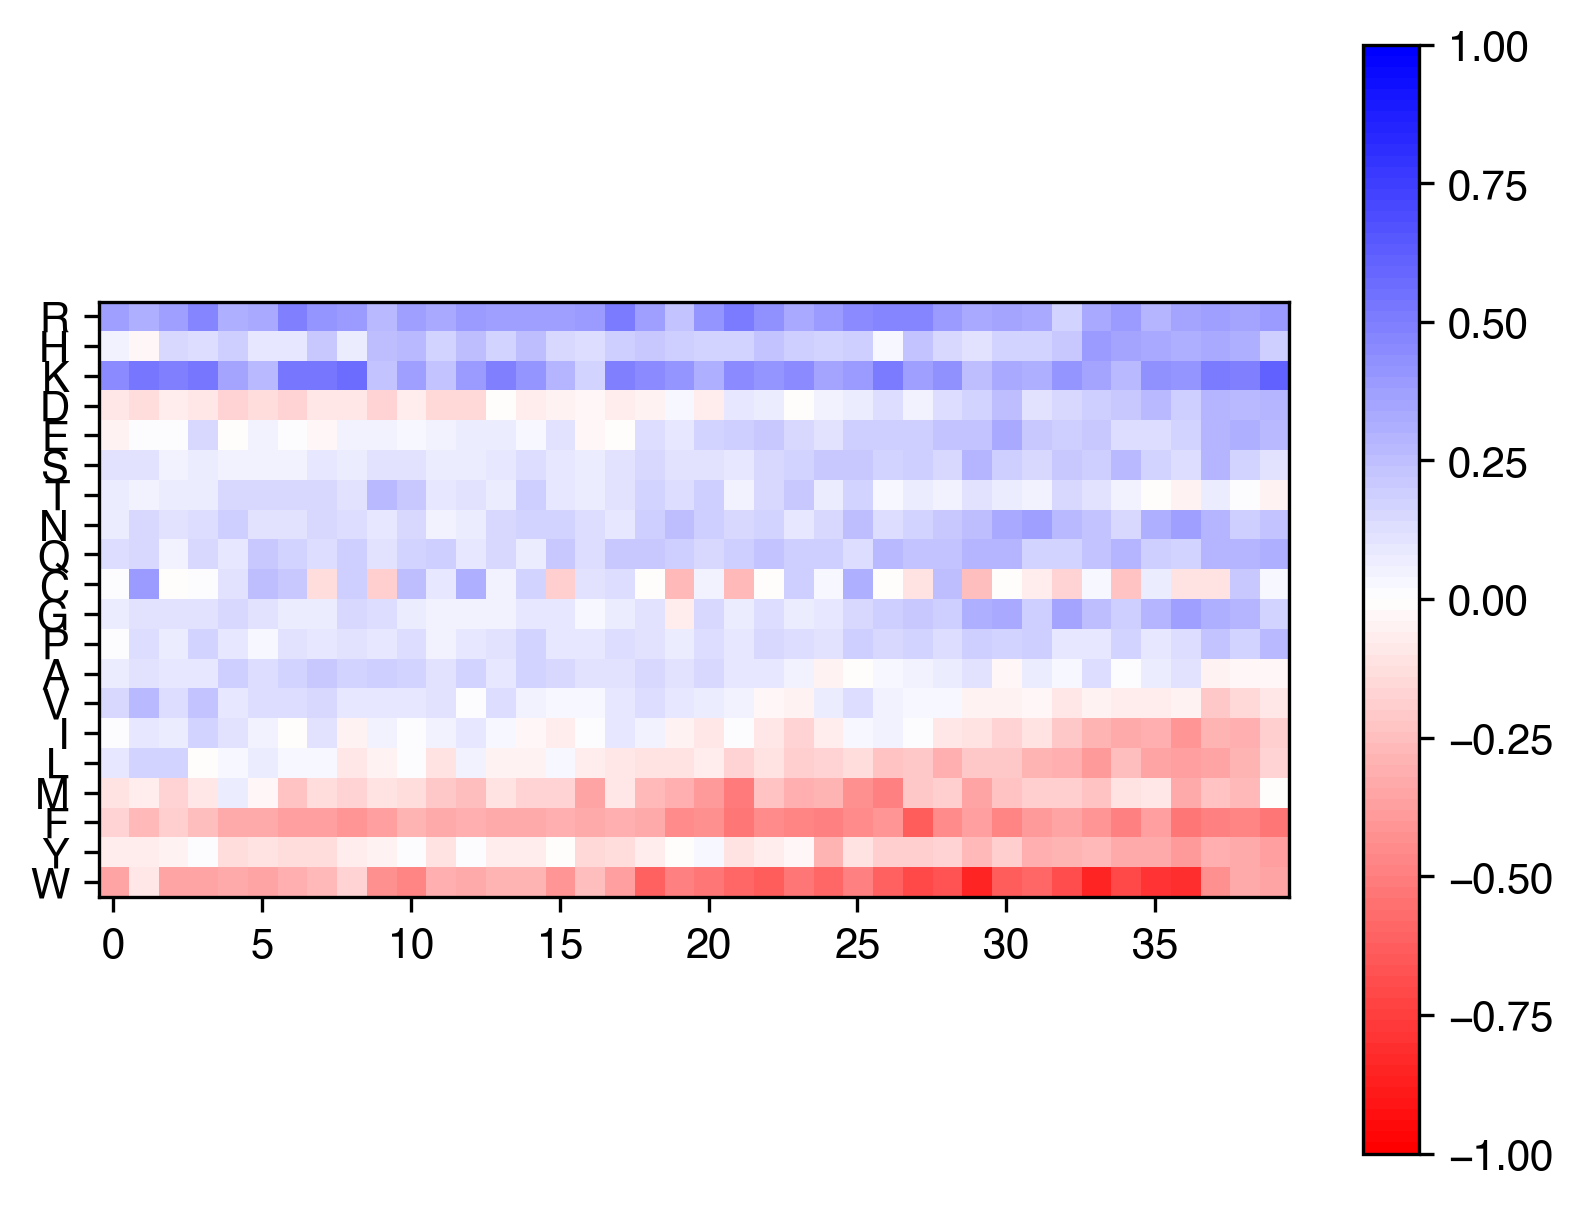

In [147]:
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Red, White, Blue
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# plt.imshow(real_weight_ls[0, 2, :, :].T, cmap=custom_cmap)
plt.imshow(conv_weights.T, cmap=custom_cmap, vmin=-1, vmax=1)
plt.yticks(range(20), aa_order)  # Label y-axis with aa names
plt.colorbar()

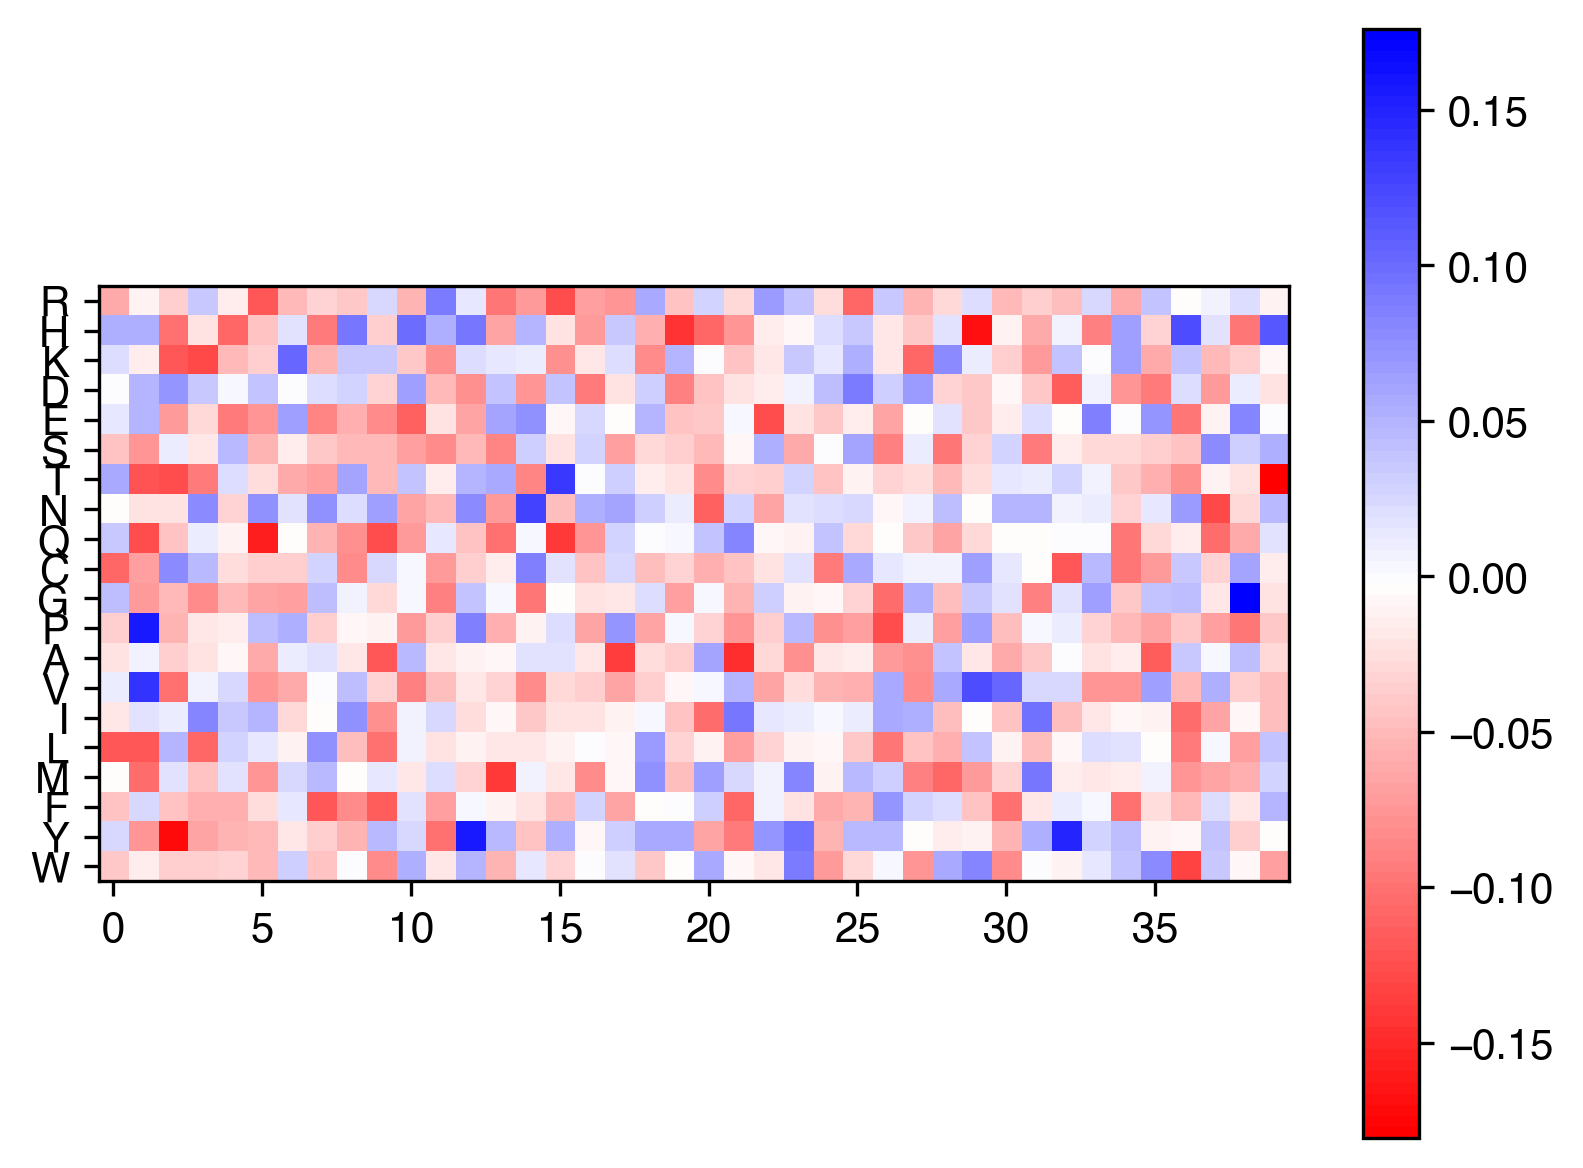

In [92]:
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Red, White, Blue
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

plt.imshow(shuffled_weight_ls[1, 0, :, :].T, cmap=custom_cmap)
plt.yticks(range(20), aa_order)  # Label y-axis with aa names
plt.colorbar()

In [95]:
# Significantly larger (more positive): 
for i in range(0, 20):
    shuffles = sum_ls[:, :, i].flatten()
    real_weight_sum = real_weight_ls[0, :, :, i].sum(axis=1)
    neg_weight_filter = (real_linear_weight_ls > 0).all(axis=2)

    print(f"aa: {aa_order[i]}", sum(shuffles > real_weight_sum[0].min()) / len(shuffles))

aa: R 0.0
aa: H 0.0
aa: K 0.0
aa: D 0.0
aa: E 0.0
aa: S 0.0
aa: T 0.0
aa: N 0.0
aa: Q 0.0
aa: C 0.0
aa: G 0.0
aa: P 0.0
aa: A 0.0
aa: V 0.0
aa: I 1.0
aa: L 1.0
aa: M 1.0
aa: F 1.0
aa: Y 1.0
aa: W 1.0


# Downsampling code - not going to use downsampling

In [567]:
# Downsampling

# weight_ls dim
# Dim 1: Shuffle number
# Dim 2: seed
# Dim 3: kernel size
# Dim 4: aa num (20)

vars_ls = np.zeros((4, 39, 100, 2))

# i loops through shuffles
for i in tqdm(range(1, 40)):
    for j in range(100):
        rng = np.random.default_rng()

        downsample_10 = calculate_simiarities(rng.permutation(shuffled_weight_ls[i], axis=0)[0:10, :, :])[0] 
        downsample_10_mean = np.mean(downsample_10)
        downsample_10_var = np.var(downsample_10)

        downsample_15 = calculate_simiarities(rng.permutation(shuffled_weight_ls[i], axis=0)[0:15, :, :])[0] 
        downsample_15_mean = np.mean(downsample_15)
        downsample_15_var = np.var(downsample_15)

        downsample_20 = calculate_simiarities(rng.permutation(shuffled_weight_ls[i], axis=0)[0:20, :, :])[0] 
        downsample_20_mean = np.mean(downsample_20)
        downsample_20_var = np.var(downsample_20)

        downsample_30 = calculate_simiarities(rng.permutation(shuffled_weight_ls[i], axis=0)[0:30, :, :])[0] 
        downsample_30_mean = np.mean(downsample_30)
        downsample_30_var = np.var(downsample_30)

        vars_ls[0, i-1, j, 0] = downsample_10_mean
        vars_ls[0, i-1, j, 1] = downsample_10_var

        vars_ls[1, i-1, j, 0] = downsample_15_mean
        vars_ls[1, i-1, j, 1] = downsample_15_var

        vars_ls[2, i-1, j, 0] = downsample_20_mean
        vars_ls[2, i-1, j, 1] = downsample_20_var

        vars_ls[3, i-1, j, 0] = downsample_30_mean
        vars_ls[3, i-1, j, 1] = downsample_30_var

# Dim 1: downsample type
# Dim 2: Shuffle #
# Dim 3: Permutation repeat (100 total) --> For 30, should be the same per shuffle
# Dim 4: Var or mean 

 97%|█████████▋| 38/39 [07:46<00:12, 12.33s/it]/Users/claireleblanc/miniconda3/envs/predictors_simple/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/claireleblanc/miniconda3/envs/predictors_simple/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_90743/3736113515.py:23: RuntimeWarning: invalid value encountered in scalar divide
  cos_sim = np.sum(weight_matrix[i] * weight_matrix[j]) / (np.linalg.norm(weight_matrix[i]) * np.linalg.norm(weight_matrix[j]))
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_90743/3736113515.py:28: RuntimeWarning: invalid value encountered in scalar divide
  cross_corr = np.max(C_1) / (np.linalg.norm(weight_matrix[i]) * np.linalg.norm(weight_matrix[j]))


0 1
0 2
0 3
0 4
0 5
0 7
0 8
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
6 1
6 2
6 3
6 4
6 5
6 7
6 8
7 0
7 1
7 2
7 3
7 4
7 5
7 6
7 7
7 8
7 9
8 0
8 1
8 2
8 3
8 4
8 5
8 6
8 7
8 8
8 9
9 1
9 2
9 3
9 4
9 5
9 7
9 8
0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
2 0
2 1
2 3
2 5
2 6
2 7
2 10
2 11
2 12
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
4 0
4 1
4 3
4 5
4 6
4 7
4 10
4 11
4 12
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11
5 12
5 13
5 14
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
6 9
6 10
6 11
6 12
6 13
6 14
7 0
7 1
7 2
7 3
7 4
7 5
7 6
7 7
7 8
7 9
7 10
7 11
7 12
7 13
7 14
8 0
8 1
8 3
8 5
8 6
8 7
8 10
8 11
8 12
9 0
9 1
9 3
9 5
9 6
9 7
9 10
9 11
9 12
10 0
10 1
10 2
10 3
10 4
10 5
10 6
10 7
10 8
10 9
10 10
10 11
10 12
10 13
10 14
11 0
11 1


100%|██████████| 39/39 [07:59<00:00, 12.30s/it]

19 7
19 8
19 9
19 10
19 11
19 12
19 13
19 14
19 15
19 16
19 17
19 18
19 19
19 20
19 21
19 22
19 23
19 24
19 25
19 26
19 27
19 28
19 29
20 2
20 3
20 5
20 6
20 8
20 9
20 13
20 14
20 15
20 16
20 17
20 19
20 21
20 23
20 25
20 27
20 28
21 0
21 1
21 2
21 3
21 4
21 5
21 6
21 7
21 8
21 9
21 10
21 11
21 12
21 13
21 14
21 15
21 16
21 17
21 18
21 19
21 20
21 21
21 22
21 23
21 24
21 25
21 26
21 27
21 28
21 29
22 2
22 3
22 5
22 6
22 8
22 9
22 13
22 14
22 15
22 16
22 17
22 19
22 21
22 23
22 25
22 27
22 28
23 0
23 1
23 2
23 3
23 4
23 5
23 6
23 7
23 8
23 9
23 10
23 11
23 12
23 13
23 14
23 15
23 16
23 17
23 18
23 19
23 20
23 21
23 22
23 23
23 24
23 25
23 26
23 27
23 28
23 29
24 2
24 3
24 5
24 6
24 8
24 9
24 13
24 14
24 15
24 16
24 17
24 19
24 21
24 23
24 25
24 27
24 28
25 0
25 1
25 2
25 3
25 4
25 5
25 6
25 7
25 8
25 9
25 10
25 11
25 12
25 13
25 14
25 15
25 16
25 17
25 18
25 19
25 20
25 21
25 22
25 23
25 24
25 25
25 26
25 27
25 28
25 29
26 2
26 3
26 5
26 6
26 8
26 9
26 13
26 14
26 15
26 16
26 17
26 19
2

In [532]:
vars_ls[3, 0:1, :101, 0]

array([[0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173, 0.173,
        0.173]])

In [ ]:
vars_ls[:, :10, :10, :]

array([[[[0.218, 0.071],
         [0.261, 0.065],
         [0.212, 0.073],
         ...,
         [0.243, 0.068],
         [0.256, 0.065],
         [0.231, 0.070]],

        [[0.247, 0.068],
         [0.238, 0.069],
         [0.245, 0.068],
         ...,
         [0.235, 0.069],
         [0.234, 0.069],
         [0.257, 0.065]],

        [[0.244, 0.067],
         [0.225, 0.071],
         [0.210, 0.074],
         ...,
         [0.231, 0.069],
         [0.221, 0.071],
         [0.226, 0.069]],

        ...,

        [[0.000, 0.000],
         [0.000, 0.000],
         [0.000, 0.000],
         ...,
         [0.000, 0.000],
         [0.000, 0.000],
         [0.000, 0.000]],

        [[0.000, 0.000],
         [0.000, 0.000],
         [0.000, 0.000],
         ...,
         [0.000, 0.000],
         [0.000, 0.000],
         [0.000, 0.000]],

        [[0.000, 0.000],
         [0.000, 0.000],
         [0.000, 0.000],
         ...,
         [0.000, 0.000],
         [0.000, 0.000],
         [0.000, 

In [376]:
shuffled_weight_ls[1].shape

(30, 10, 20)

In [ ]:
# No replacement, sum is the same every time

# Caclulate cosine simiarity between all positions
rng.permuted(shuffled_weight_ls[1][0:30, :, :]).sum()

-237.53081704384567

In [405]:
permuted_ls = rng.permuted(shuffled_weight_ls[1][0:30, :, :])

In [415]:
30 * 30

900

In [491]:
# Calculate the Frobenius distance
# The 'ord="fro"' argument specifies the Frobenius norm
from scipy.signal import correlate2d

def calculate_simiarities(weight_matrix):
    cosine_similarities = []
    correlations = []
    cross_correlations = []

    # Looping through all matrix positions
    max_dim = weight_matrix.shape[0]
    for i in range(max_dim):
        for j in range(max_dim):
            # distance = np.linalg.norm(real_weight_ls[i] - real_weight_ls[j], ord="fro") # This is bad because it doesn't ignore differences in magnitude
            
            # Correlating two matricies
            correlation = np.corrcoef(weight_matrix[i].flatten(),weight_matrix[j].flatten())[0][1] #np.corrcoef(real_weight_ls[i],real_weight_ls[j] )
            if np.isnan(correlation):
                print(i, j)
            correlations.append(correlation)

            # Cosine similarity 
            cos_sim = np.sum(weight_matrix[i] * weight_matrix[j]) / (np.linalg.norm(weight_matrix[i]) * np.linalg.norm(weight_matrix[j]))
            cosine_similarities.append(cos_sim)
            
            # cross correlation
            C_1 = correlate2d(weight_matrix[i], weight_matrix[j], mode='same')
            cross_corr = np.max(C_1) / (np.linalg.norm(weight_matrix[i]) * np.linalg.norm(weight_matrix[j]))
            cross_correlations.append(cross_corr)
    
    return cosine_similarities, correlations, cross_correlations

In [459]:
# First dim is shuffle
# Second dim is seed
# Third dem in k size
# Fourth dem is aa
# We want to sample: Different kernels --> Permute second dimension

shuffled_weight_ls[1, :, :, :].shape

(30, 10, 20)

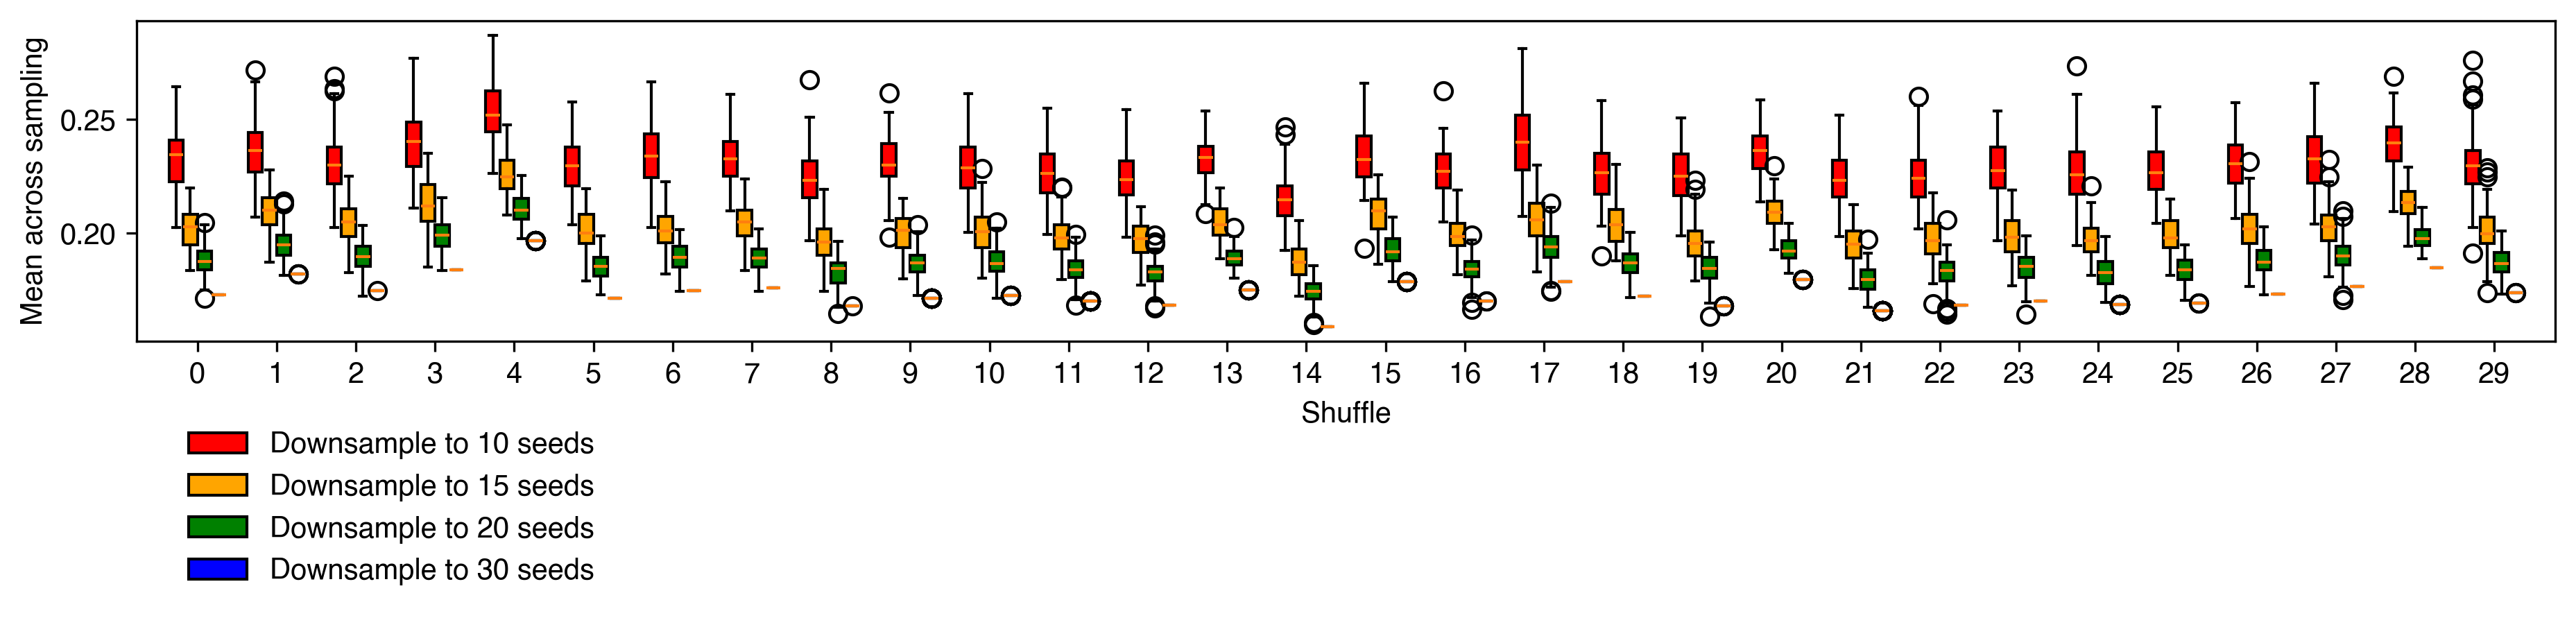

In [547]:
# What is spread of means for each rep and downsample? 
# What is the spread of variances for each rep and downsample

width = 0.18
n = vars_ls[0, 0:30, :, 0].reshape(100,30).shape[1]
base = np.arange(n)

fig, axs = plt.subplots(1, 1, figsize=(15, 2))

# For var_ls
# Dim 1: downsample type
# Dim 2: Shuffle #
# Dim 3: Permutation repeat (100 total) --> For 30, should be the same per shuffle
# Dim 4: Var or mean 
 
# Ten seeds
# vars_ls[0, 0:30, :, 0] --> First downsample type, all thirty shuffles, all repeats, mean --> Reshape to be repeat x shuffle (each shuffle gets separate box plot)
plt.boxplot(vars_ls[0, 0:30, :, 0].squeeze().squeeze().T, positions=base - 1.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='red'), label="Downsample to 10 seeds")

# Fifteen seeds
plt.boxplot(vars_ls[1, 0:30, :, 0].squeeze().squeeze().T, positions=base - 0.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='orange'), label="Downsample to 15 seeds")

# Twenty seeds
plt.boxplot(vars_ls[2, 0:30, :, 0].squeeze().squeeze().T, positions=base + 0.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='green'), label="Downsample to 20 seeds")

# Thirty seeds
plt.boxplot(vars_ls[3, 0:30, :, 0].squeeze().squeeze().T, positions=base + 1.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='blue'), label="Downsample to 30 seeds")

plt.xlabel("Shuffle")
plt.ylabel("Mean across sampling")
plt.xticks(range(0, 30), range(0, 30))
plt.legend(frameon=False, bbox_to_anchor = (0.2, -0.2))

plt.show()

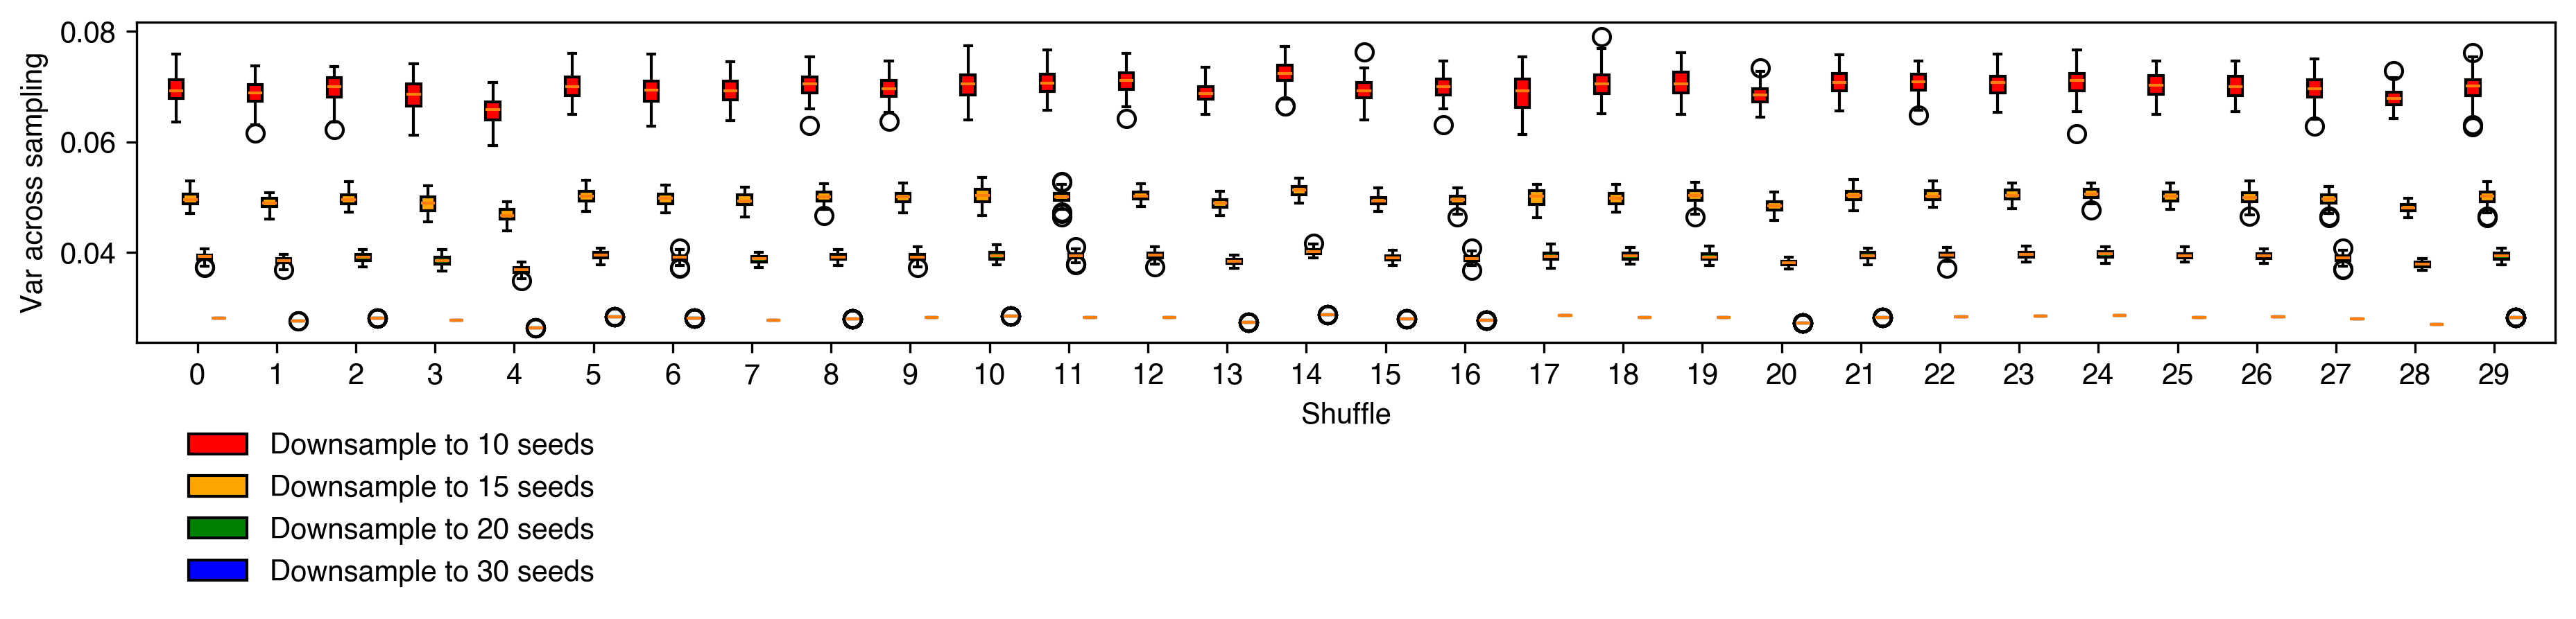

In [549]:
# What is spread of means for each rep and downsample? 
# What is the spread of variances for each rep and downsample

width = 0.18
n = vars_ls[0, 0:30, :, 0].reshape(100,30).shape[1]
base = np.arange(n)

fig, axs = plt.subplots(1, 1, figsize=(15, 2))

plt.boxplot(vars_ls[0, 0:30, :, 1].squeeze().squeeze().T, positions=base - 1.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='red'), label="Downsample to 10 seeds")
plt.boxplot(vars_ls[1, 0:30, :, 1].squeeze().squeeze().T, positions=base - 0.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='orange'), label="Downsample to 15 seeds")
plt.boxplot(vars_ls[2, 0:30, :, 1].squeeze().squeeze().T, positions=base + 0.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='green'), label="Downsample to 20 seeds")
plt.boxplot(vars_ls[3, 0:30, :, 1].squeeze().squeeze().T, positions=base + 1.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='blue'), label="Downsample to 30 seeds")

plt.xlabel("Shuffle")
plt.ylabel("Var across sampling")
plt.xticks(range(0, 30), range(0, 30))
plt.legend(frameon=False, bbox_to_anchor = (0.2, -0.2))

plt.show()

In [ ]:
real_cosine_similarities, real_correlations, real_cross_correlations = calculate_simiarities(real_weight_ls.squeeze())

In [553]:
np.mean(cosine_similarities)

nan

In [568]:
1/100

0.01

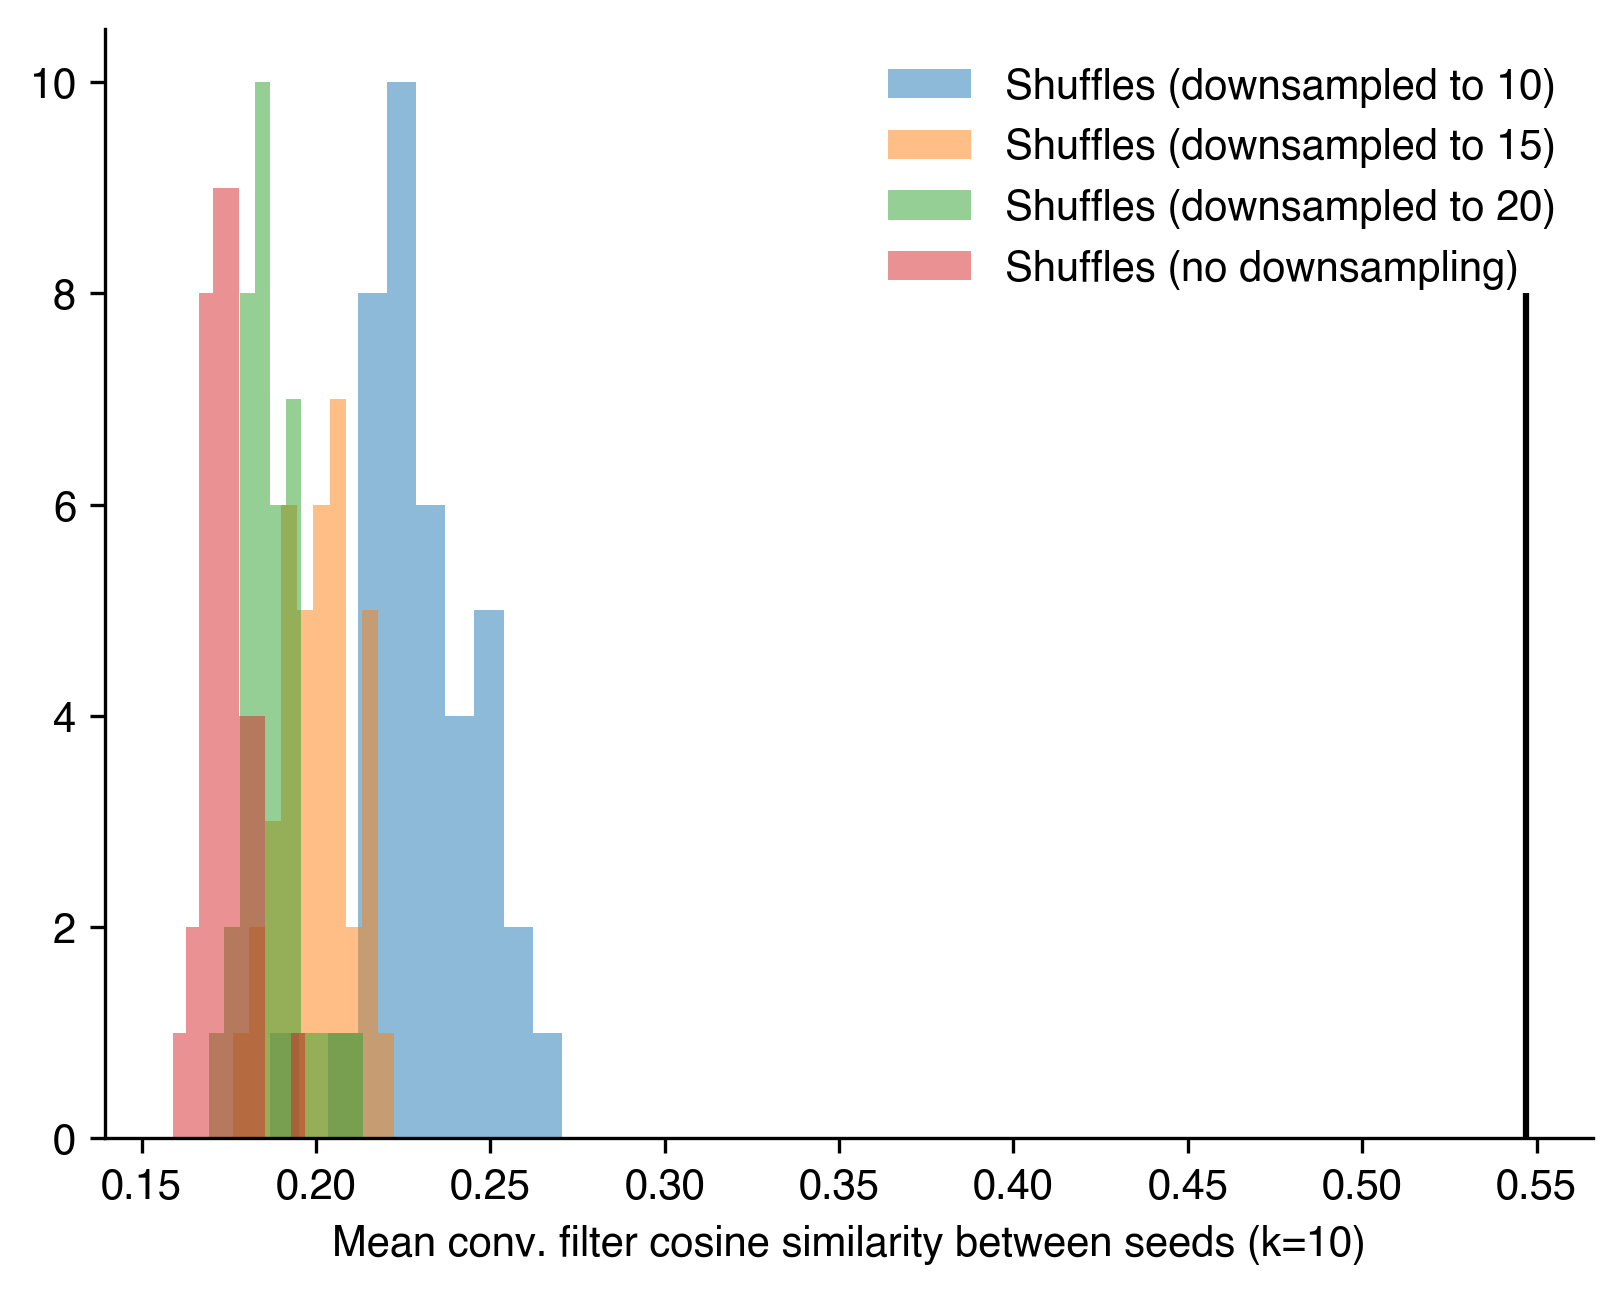

In [564]:
# cosine_means = [np.mean(sub_ls) for sub_ls in cosine_sim_ls]
plt.hist(vars_ls[0, :, 0, 0], label="Shuffles (downsampled to 10)", alpha=0.5)
plt.hist(vars_ls[1, :, 0, 0], label="Shuffles (downsampled to 15)", alpha=0.5)
plt.hist(vars_ls[2, :, 0, 0], label="Shuffles (downsampled to 20)", alpha=0.5)
plt.hist(vars_ls[3, :, 0, 0], label="Shuffles (no downsampling)", alpha=0.5)

plt.vlines(np.mean(real_cosine_similarities), ymin=0, ymax=8, color = 'black')
plt.xlabel("Mean conv. filter cosine similarity between seeds (k=10)")

plt.legend(frameon=False)
sns.despine()

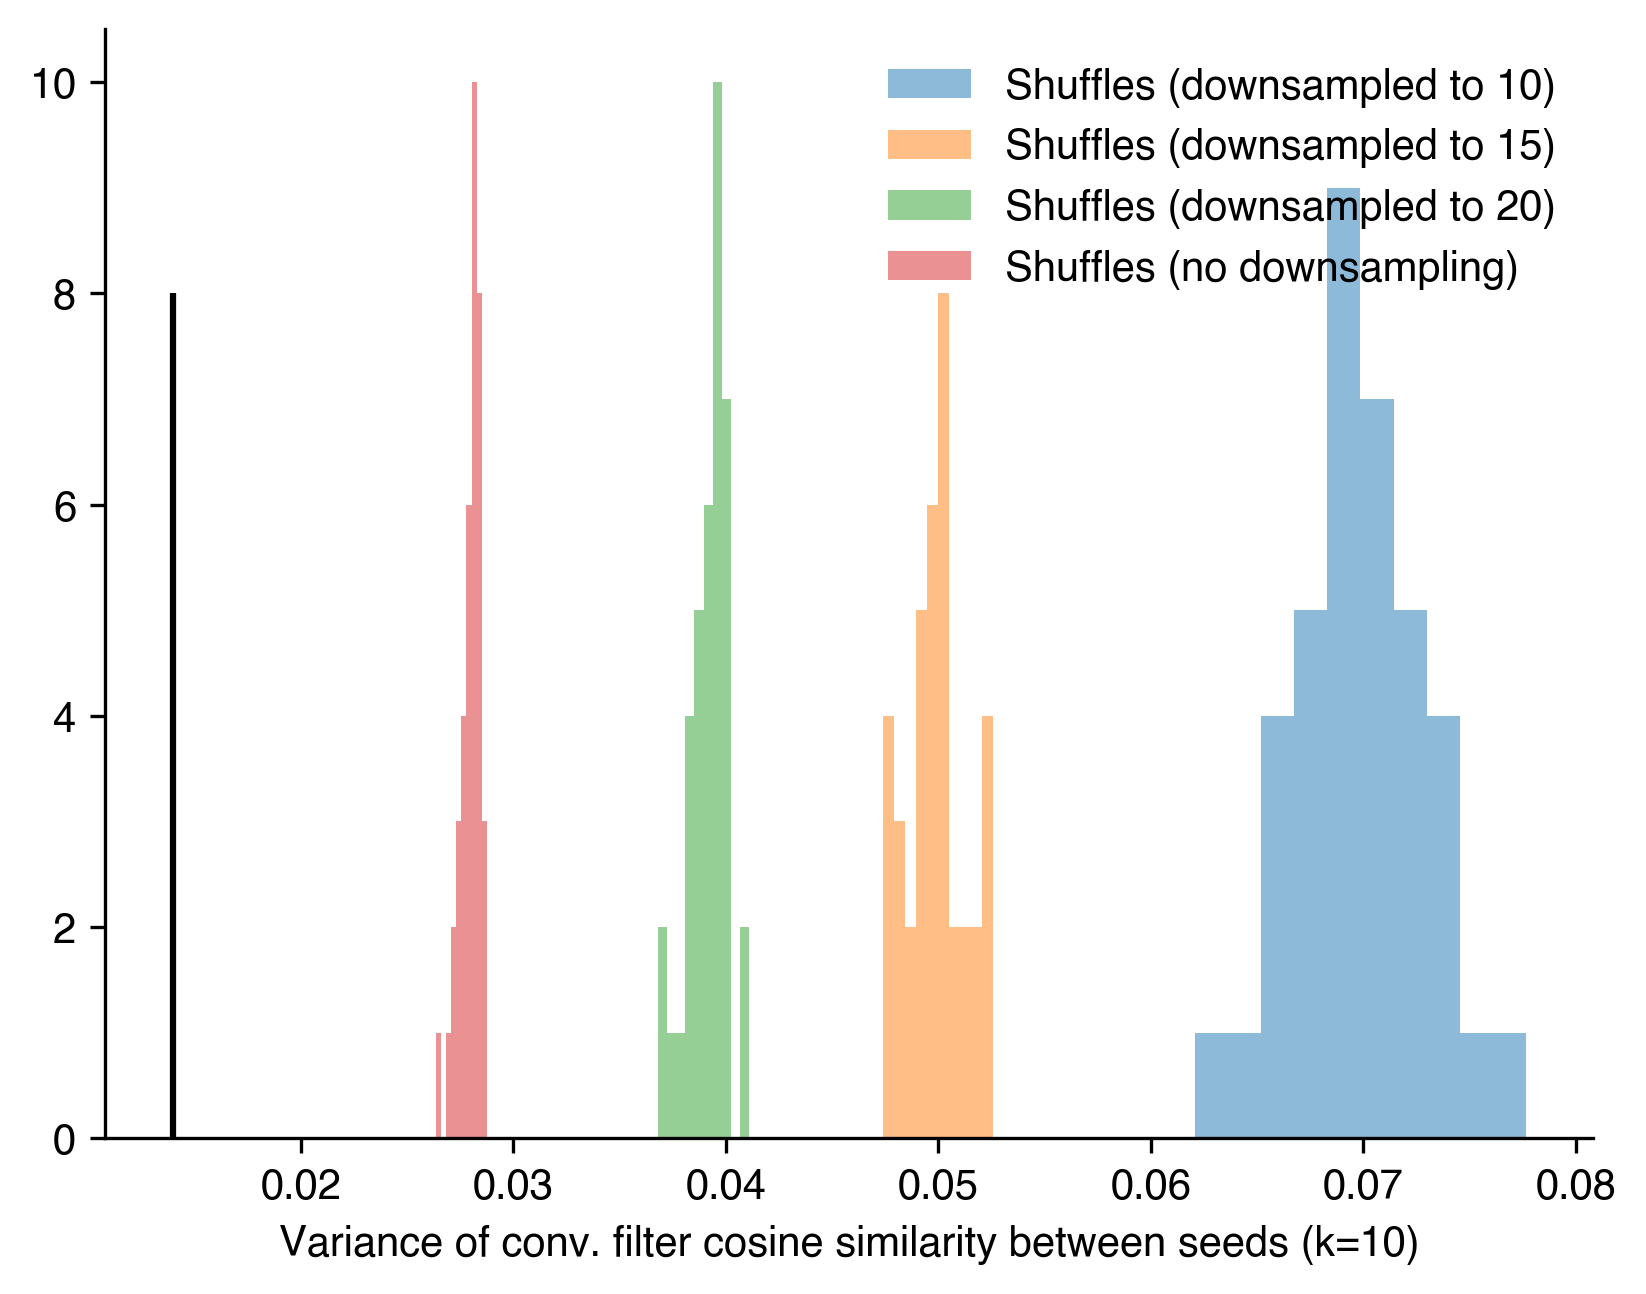

In [566]:
# cosine_means = [np.mean(sub_ls) for sub_ls in cosine_sim_ls]
plt.hist(vars_ls[0, :, 0, 1], label="Shuffles (downsampled to 10)", alpha=0.5)
plt.hist(vars_ls[1, :, 0, 1], label="Shuffles (downsampled to 15)", alpha=0.5)
plt.hist(vars_ls[2, :, 0, 1], label="Shuffles (downsampled to 20)", alpha=0.5)
plt.hist(vars_ls[3, :, 0, 1], label="Shuffles (no downsampling)", alpha=0.5)

plt.vlines(np.var(real_cosine_similarities), ymin=0, ymax=8, color = 'black')
plt.xlabel("Variance of conv. filter cosine similarity between seeds (k=10)")

plt.legend(frameon=False)
sns.despine()